In [166]:
import os
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.types import Send
from langchain_core.messages import HumanMessage, AIMessage,SystemMessage
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq
from typing import List,TypedDict,Annotated,Literal
from pydantic import BaseModel,Field
from langchain_core.prompts import PromptTemplate
import operator

In [167]:
model=ChatGroq(model='llama-3.3-70b-versatile',temperature=0.2,api_key=os.getenv('GROQ_API_KEY'))

In [168]:
class Task(BaseModel):
    id:int
    title:str
    goal:str=Field(...,description="one line description of the task")
    bullets:List[str]=Field(...,min_length=3,max_length=5,description="a list of bullet points describing the task in more detail")
    target_words:int=Field(...,description="the target word count for the task")
    section_type:Literal["intro","core","example","checklist","common_mistake","conclusion"]=Field(...,description="Use common mistake only once in the task")
    

In [169]:
class Plan(BaseModel):
    blog_title:str
    audience:str=Field(...,description="The target audience for the blog post")
    tone:str=Field(...,description="The tone of the blog post, e.g., formal, informal, humorous, etc.")
    task:List[Task]


In [170]:
class Blogstate(TypedDict):
    topic:str
    plan:Plan 
    sections:Annotated[List[str],operator.add]
    final:str

In [171]:
def orchestrator(state:Blogstate):
    plannaer=model.with_structured_output(Plan)

    plan=plannaer.invoke([
        SystemMessage(content="You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
                ),
                HumanMessage(content=f"topic:{state['topic']}")
                ])
    
    return {
        "plan":plan
    }

In [172]:
def fanout(state:Blogstate):
    return[
        Send("worker",{"task":task,"topic":state['topic'],"plan":state["plan"]})
             for task in state["plan"].task
    ]

In [173]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md = model.invoke(
        [
            SystemMessage(
    content=(
        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"
    )
)
,
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [174]:
from pathlib import Path

def reducer(state:Blogstate):

    title=state['plan'].blog_title
    body="\n\n".join(state['sections']).strip()

    final_md=f"# {title}\n\n{body}\n"

    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {
        "final":final_md
    }

In [175]:
builder=StateGraph(Blogstate)
builder.add_node("orchestrator", orchestrator)
builder.add_node("worker", worker)
builder.add_node("reducer", reducer)



In [176]:
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator",fanout,["worker"])
builder.add_edge("worker","reducer")
builder.add_edge("reducer",END)


In [177]:
graph=builder.compile()

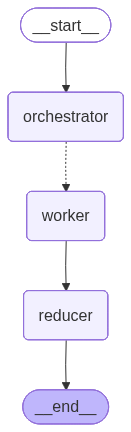

In [178]:
graph

In [179]:
result=graph.invoke({
    "topic":"Ai in industry"})

result

{'topic': 'Ai in industry',
 'plan': Plan(blog_title='Practical Applications of AI in Industry', audience='developers', tone='technical', task=[Task(id=1, title='Introduction to AI in Industry', goal='Understand the current state of AI adoption in industry', bullets=['Show a graph of AI adoption rates in various industries', 'Explain the concept of Industry 4.0 and its relation to AI', 'Provide a list of top 5 industries that have seen significant AI adoption'], target_words=200, section_type='intro'), Task(id=2, title='Core Concepts of AI', goal='Understand the fundamental concepts of AI and its applications', bullets=['Define supervised, unsupervised, and reinforcement learning with examples', 'Show a minimal working example (MWE) of a neural network in Python', 'Explain the concept of transfer learning and its benefits'], target_words=300, section_type='core'), Task(id=3, title='AI Implementation in Industry', goal='Learn how to implement AI solutions in industrial settings', bullet

In [181]:
result2=graph.invoke({
    "topic":"Best practices for building with large language models"})

result2

{'topic': 'Best practices for building with large language models',
 'plan': Plan(blog_title='Best Practices for Building with Large Language Models', audience='developers', tone='formal', task=[Task(id=1, title='Introduction to Large Language Models', goal='Understand the basics of large language models and their applications', bullets=['Define what large language models are and their current industry applications', 'Show a minimal working example of a simple language model', 'Explain the concept of transfer learning in large language models'], target_words=200, section_type='intro'), Task(id=2, title='Designing Effective Prompts', goal='Learn how to design effective prompts for large language models', bullets=['Explain the importance of prompt engineering for large language models', 'Show examples of well-designed prompts for different tasks', 'Discuss the role of few-shot learning in prompt design'], target_words=300, section_type='core'), Task(id=3, title='Common Mistakes in Buildi

In [189]:
result2['plan'].task

[Task(id=1, title='Introduction to Large Language Models', goal='Understand the basics of large language models and their applications', bullets=['Define what large language models are and their current industry applications', 'Show a minimal working example of a simple language model', 'Explain the concept of transfer learning in large language models'], target_words=200, section_type='intro'),
 Task(id=2, title='Designing Effective Prompts', goal='Learn how to design effective prompts for large language models', bullets=['Explain the importance of prompt engineering for large language models', 'Show examples of well-designed prompts for different tasks', 'Discuss the role of few-shot learning in prompt design'], target_words=300, section_type='core'),
 Task(id=3, title='Common Mistakes in Building with Large Language Models', goal='Avoid common mistakes when building with large language models', bullets=['Discuss the pitfalls of overfitting and underfitting in large language models',